# 01 — Initial exploration

**Mock data only.** This notebook is for building/testing the pipeline
(DB → pandas → plots), not for drawing conclusions about vehicle
behavior — any correlations here are artifacts of the mock generator,
not real signal. Swapping in real data later should require no changes
below, just new rows underneath.

In [ ]:
import sys, os

# diagnostic — confirm kernel/env are what we expect before doing anything else
print("Python executable:", sys.executable)
print("PYTHONPATH env var:", repr(os.environ.get("PYTHONPATH")))
print("ROS-looking paths in sys.path:", [p for p in sys.path if "ros" in p.lower()] or "none")

Python executable: /home/buvindu-suraweera/vehicle-telemetry-platform/analytics/.venv/bin/python
PYTHONPATH env var: None
ROS-looking paths in sys.path: none


In [ ]:
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.session_summary import load_session_telemetry, list_sessions

sns.set_theme(style="darkgrid")

## Connection check

In [ ]:
sessions = list_sessions()
sessions

,session_id,driver_id,started_at,ended_at,notes,row_count
0,mock_001,driver_a,2026-07-16 16:18:08.923735+05:30,2026-07-16 18:06:05.448023+05:30,Mock data session,64619
1,live_001,driver_a,2026-07-16 16:18:08.923735+05:30,2026-07-16 18:06:05.448023+05:30,Live OBD session,64619
2,580b6bf4d35a496ba3d0492feae04a60,driver_a,2026-07-23 18:47:05.252985+05:30,2026-07-23 18:49:35.700267+05:30,NaN,0
3,f54d93764251441ab94d3fd89a96e910,NaN,2026-07-26 11:56:52.935421+05:30,2026-07-26 11:57:23.600341+05:30,UI session creation test 1,0
4,68547f507679411a99ab91fe356ded46,driver_a,2026-07-26 11:59:00.670896+05:30,2026-07-26 11:59:18.080642+05:30,NaN,0
5,real_obd_001,driver_a,2026-07-26 15:17:21.037000+05:30,2026-07-26 15:49:11.384000+05:30,"Real vehicle OBD, mock IMU — first hardware ca...",2410


## Pull raw telemetry

Adjust `session_id` below to whichever session the migrated mock data
actually landed under.

In [ ]:
SESSION_ID = "real_obd_001"

df = load_session_telemetry(SESSION_ID)
print(df.shape)
df.head()

(2410, 12)


,time,speed_kmh,rpm,throttle_pct,coolant_temp_c,engine_load_pct,accel_x,accel_y,accel_z,latitude,longitude,node_id
0,2026-07-26 15:17:21.037710+05:30,0.0,0.0,17.647,44.0,0.0,0.337,-0.020,9.856,None,None,None
1,2026-07-26 15:17:21.933809+05:30,0.0,0.0,17.647,44.0,0.0,-0.013,-0.053,9.741,None,None,None
2,2026-07-26 15:17:22.723591+05:30,0.0,0.0,17.647,44.0,0.0,-0.113,-0.032,9.891,None,None,None
3,2026-07-26 15:17:23.212319+05:30,0.0,0.0,17.647,44.0,0.0,0.180,0.059,9.842,None,None,None
4,2026-07-26 15:17:23.739199+05:30,0.0,0.0,17.647,44.0,0.0,-0.135,-0.003,9.836,None,None,None


In [ ]:
df.describe()

,speed_kmh,rpm,throttle_pct,coolant_temp_c,engine_load_pct,accel_x,accel_y,accel_z
count,2404.000000,2400.000000,2401.000000,2400.000000,2388.000000,2410.000000,2410.000000,2410.000000
mean,27.319052,449.983229,20.380187,78.713750,26.465333,0.009712,0.001085,9.808889
std,20.400324,713.022451,5.360134,13.738679,40.152263,0.298002,0.100123,0.048790
min,0.000000,0.000000,13.725000,43.000000,0.000000,-1.003000,-0.344000,9.631000
25%,6.750000,0.000000,17.647000,81.000000,0.000000,-0.184000,-0.065000,9.777000
50%,28.000000,0.000000,17.647000,85.000000,0.000000,0.017500,0.002000,9.808000
75%,44.250000,1135.375000,20.784000,86.000000,82.745000,0.213000,0.066750,9.842000
max,69.000000,2426.500000,34.510000,89.000000,99.216000,1.097000,0.337000,9.970000


## First-look plots

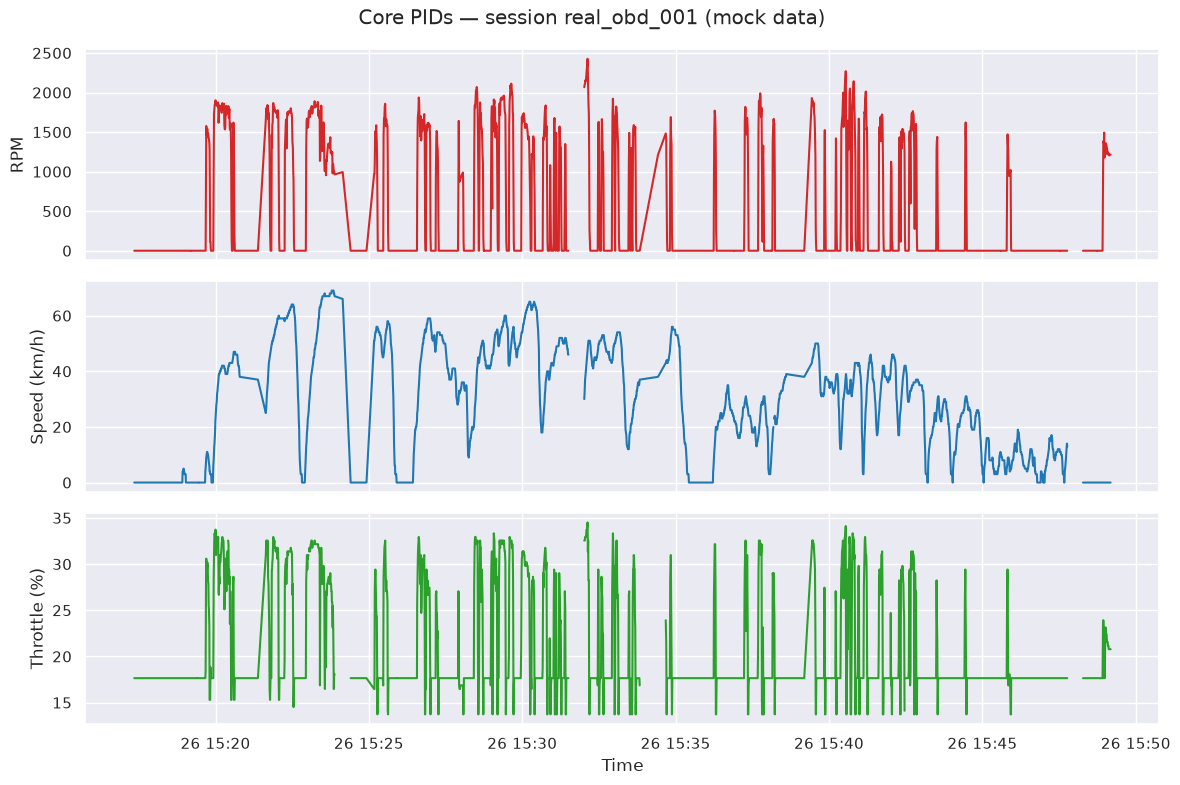

In [ ]:
# Core PIDs over time — sanity check that the shapes look sane, not an
# analysis conclusion
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df["time"], df["rpm"], color="tab:red")
axes[0].set_ylabel("RPM")

axes[1].plot(df["time"], df["speed_kmh"], color="tab:blue")
axes[1].set_ylabel("Speed (km/h)")

axes[2].plot(df["time"], df["throttle_pct"], color="tab:green")
axes[2].set_ylabel("Throttle (%)")
axes[2].set_xlabel("Time")

fig.suptitle(f"Core PIDs — session {SESSION_ID}")
fig.tight_layout()

<Axes: xlabel='time'>

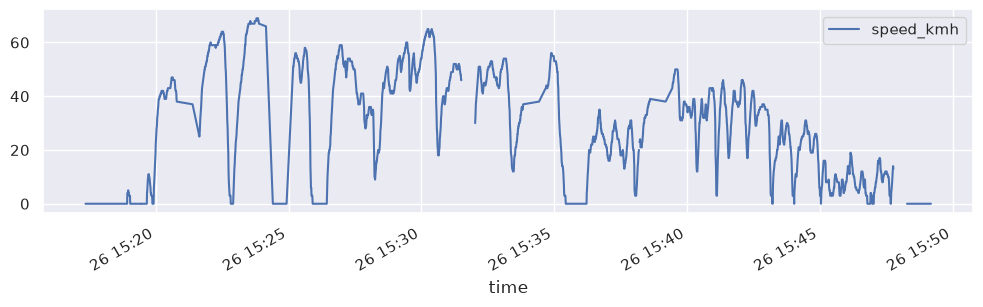

In [ ]:
df["speed_kmh"].describe()
df.plot(x="time", y="speed_kmh", figsize=(12, 3))

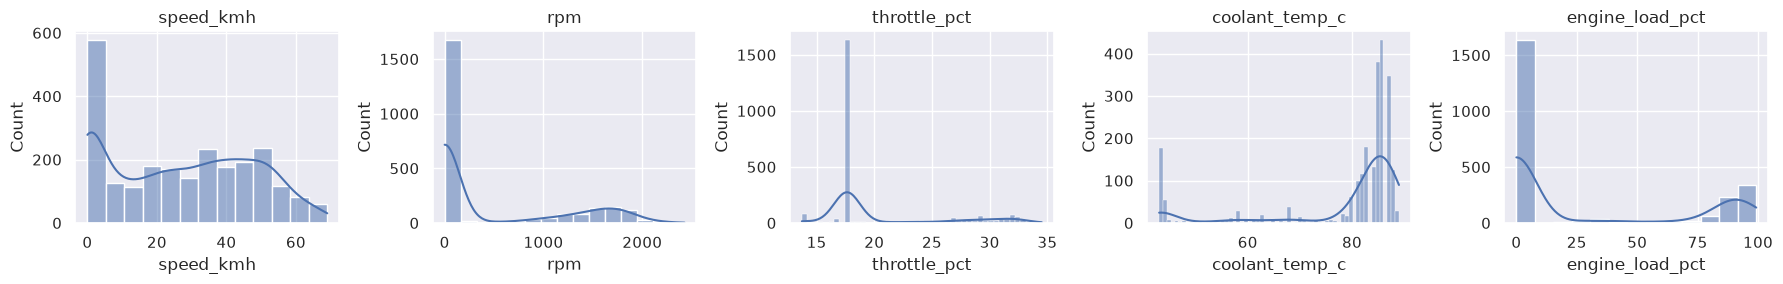

In [ ]:
# Distributions — quick shape check across all core PIDs
core_pids = ["speed_kmh", "rpm", "throttle_pct", "coolant_temp_c", "engine_load_pct"]

fig, axes = plt.subplots(1, len(core_pids), figsize=(18, 3))
for ax, col in zip(axes, core_pids):
    sns.histplot(df[col].dropna(), ax=ax, kde=True)
    ax.set_title(col)
fig.tight_layout()

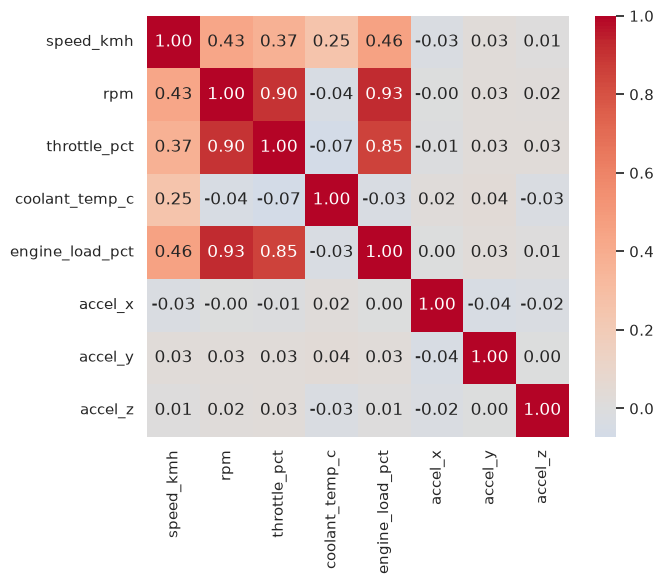

In [ ]:
# Correlation matrix — pipeline check only. Do NOT read anything into
# these values while the data is synthetic — correlations here reflect
# the mock generator's own logic, not vehicle behavior.
corr = df[core_pids + ["accel_x", "accel_y", "accel_z"]].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
fig.tight_layout()